# Baseline Demo for neural signal forecasting

In [13]:
# Build dataloader
import torch
import numpy as np
import os
from tqdm.auto import tqdm

input_dir = './'

In [14]:
# prompt: write a function for torch dataloader

from torch.utils.data import DataLoader, Dataset, TensorDataset


def load_dataset(filename):
    """
    Load test dataset from file.

    Args:
        filename: Name of the test data file

    Returns:
        train_data: Samples to train with shape
                  (num_samples, num_timestep, num_channels, num_bands)
        test_data: Samples to test with shape
                  (num_samples, num_timestep, num_channels, num_bands)
        val_data: Samples to validate with shape
                  (num_samples, num_timestep, num_channels, num_bands)
    """
    test_file = os.path.join(input_dir, filename)
    # Open the file and load the data
    # split into train(80%), test(10%), val(10%)
    data = np.load(test_file)['arr_0']
    train_data = data[:int(len(data)*0.8)]
    test_data = data[int(len(data)*0.8):int(len(data)*0.9)]
    val_data = data[int(len(data)*0.9):]

    return train_data, test_data, val_data


def normalize(data, average=[], std=[]):
    # normalizing input to the range of [~mean - 4*std, ~mean + 4*std]
    # becasue in this dataset, the timestep is in first dimension.
    # adapt the normalization to fit this situation, compute mean and std in axis 0
    if data.ndim == 4:
        n, t, c, f = data.shape
        data = data.reshape((n*t, -1))  # neuron input
    if len(average) == 0:
        average = np.mean(data, axis=0, keepdims=True)
        std = np.std(data, axis=0, keepdims=True)
    combine_max = average + 4 * std
    combine_min = average - 4 * std
    norm_data = 2 * (data - combine_min) / (combine_max - combine_min) - 1
    norm_data = norm_data.reshape((n, t, c, f))
    return norm_data, average, std


class NeuroForcastDataset(Dataset):
  def __init__(self, neural_data, use_graph=False, average=[], std=[]):
    """
    neural_data: N*T*C*F (sampe size * total time steps * channel *feature dimension)
    f_window: T' the length of prediction window
    batch_size: batch size
    """
    self.data = neural_data
    self.use_graph = use_graph
    if len(average) == 0:
      self.data, self.average, self.std = normalize(self.data)
    else:
      self.data, self.average, self.std = normalize(self.data, average, std)

  def __len__(self) -> int:
    return len(self.data)

  def __getitem__(self, index):
    data = self.data[index]
    if not self.use_graph:
      data = data[:, :, 0]

    data = torch.tensor(data, dtype=torch.float32)
    return data


class NFBaseModel(torch.nn.Module):
  def __init__(self, input_size=96, hidden_size=256):
    super(NFBaseModel, self).__init__()
    self.encoder = torch.nn.GRU(
        input_size=input_size, hidden_size=hidden_size, num_layers=2, batch_first=True)
    self.output_layer = torch.nn.Linear(hidden_size, input_size)

  def forward(self, x):
    output, hidden = self.encoder(x)
    output = self.output_layer(output)
    return output

  def predict(self, x):
    output, hidden = self.encoder(x)
    output = self.output_layer(output)
    return output


class Trainer():
  def __init__(self, model, train_data_loader, test_data_loader,
               val_data_loader, loss_fn, optimizer, device, scheduler,
               forecasting_mode, init_steps=10, save_path='', ckpt_path=None):
    """
    Args:
      model: model to train
      train_data_loader: train data loader
      test_data_loader: test data loader
      val_data_loader: validation data loader
      loss_fn: loss function
      optimizer: optimizer
      device: device
      forecasting_mode: either 'one_step' or 'multi_step'
      init_steps: number of initial steps for multi-step forecasting

    """
    self.model = model
    self.train_data_loader = train_data_loader
    self.test_data_loader = test_data_loader
    self.val_data_loader = val_data_loader

    self.loss_fn = loss_fn
    self.optimizer = optimizer
    self.device = device
    self.forecasting_mode = forecasting_mode
    self.init_steps = init_steps

    self.save_path = save_path
    self.ckpt_path = ckpt_path
    if ckpt_path is not None:
      self.load_model(ckpt_path)
    self.model.to(device)
    self.scheduler = scheduler

    self.train_loss = []
    self.test_loss = []
    self.val_loss = []
    self.max_grad_norm = 1.0   # 防爆關鍵：grad clipping
    self.save_best = True
    self.best_val = float("inf")


  def prepare_data(self, data):
    if self.forecasting_mode == 'one_step':
      input_data = data[:, :-1, :]
      target_data = data[:, 1:, :]
    elif self.forecasting_mode == 'multi_step':
      future_step = data.shape[1] - self.init_steps
      # masking out future dataset

      input_data = torch.cat([data[:, :self.init_steps], torch.repeat_interleave(data[:, self.init_steps-1:self.init_steps],
                                                                                 future_step, dim=1)], dim=1)
      target_data = data[:, self.init_steps:]


      # print(f"input_data shape: {input_data.shape}")
      # print(f"target_data shape: {target_data.shape}")
    else:
      raise ValueError(
          'forecasting_mode must be either one_step or multi_step')
    return input_data, target_data

  def loss_function(self, prediction, target):
    if self.forecasting_mode == 'one_step':
      loss = self.loss_fn(prediction, target)
    else:
      loss = self.loss_fn(prediction[:, self.init_steps:], target)
    return loss

  def train(self, num_epochs):
    for epoch in range(num_epochs):
        self.model.train()
        running_loss = 0.0

        # 讀取當前 lr
        lr = self.optimizer.param_groups[0]["lr"] if self.optimizer is not None else None

        pbar = tqdm(
            self.train_data_loader,
            desc=f"Epoch {epoch+1}/{num_epochs}",
            leave=True,
        )

        for batch in pbar:
            batch = batch.to(self.device)
            input_data, target_data = self.prepare_data(batch)

            self.optimizer.zero_grad(set_to_none=True)
            output = self.model(input_data)

            loss = self.loss_function(output, target_data)

            # 防 NaN/Inf
            if not torch.isfinite(loss):
                pbar.set_postfix({"loss": "NaN/Inf - skipped"})
                continue

            loss.backward()

            # 防爆：gradient clipping
            if hasattr(self, "max_grad_norm") and self.max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)

            self.optimizer.step()

            running_loss += loss.item()
            avg_loss_so_far = running_loss / max(1, (pbar.n + 1))

            postfix = {"train_loss": f"{avg_loss_so_far:.6f}"}
            if lr is not None:
                postfix["lr"] = f"{lr:.2e}"
            pbar.set_postfix(postfix)

        # scheduler 每 epoch step 一次
        if self.scheduler is not None:
            self.scheduler.step()
            # 更新 lr 讓顯示更準（scheduler step 後）
            lr = self.optimizer.param_groups[0]["lr"]

        # 每個 epoch 都做 validation（你要「不要每十個才顯示」）
        self.model.eval()
        val_loss_sum = self.validation()  # 回傳 sum of batch losses（跟你原本一致）
        avg_train = running_loss / max(len(self.train_data_loader), 1)
        avg_val = val_loss_sum / max(len(self.val_data_loader), 1)

        # 每個 epoch 都印一次
        if lr is not None:
            print(f"Epoch {epoch:03d} | lr={lr:.6e} | Train={avg_train:.6f} | Val={avg_val:.6f}")
        else:
            print(f"Epoch {epoch:03d} | Train={avg_train:.6f} | Val={avg_val:.6f}")

        # 存 best checkpoint（若你已在 __init__ 設定 self.save_best / self.best_val）
        if getattr(self, "save_best", False):
            if avg_val < getattr(self, "best_val", float("inf")):
                self.best_val = avg_val
                self.save_model()
                print(f"[BEST] Saved to {self.save_path} | best_val={self.best_val:.6f}")


  @torch.no_grad()
  def validation(self):
      self.model.eval()
      val_loss = 0.0

      pbar = tqdm(self.val_data_loader, desc="Val", leave=False)

      for batch in pbar:
          batch = batch.to(self.device)
          input_data, target_data = self.prepare_data(batch)
          output = self.model(input_data)
          loss = self.loss_function(output, target_data)

          if not torch.isfinite(loss):
              pbar.set_postfix({"val_loss": "NaN/Inf - skipped"})
              continue

          val_loss += loss.item()
          avg_val_so_far = val_loss / max(1, (pbar.n + 1))
          pbar.set_postfix({"val_loss": f"{avg_val_so_far:.6f}"})

      return val_loss


  def save_model(self):
    torch.save(self.model.state_dict(), self.save_path)

  def load_model(self, path):
    self.model.load_state_dict(torch.load(self.ckpt_path))

  def prediction(self):
    self.model.eval()
    outputs_pred = []
    outputs_gt = []
    for batch in self.val_data_loader:
      batch = batch.to(self.device)
      input_data, target_data = self.prepare_data(batch)
      output = self.model(input_data)
      outputs_pred.append(output.detach().cpu().numpy())
      outputs_gt.append(target_data.detach().cpu().numpy())
    return outputs_pred, outputs_gt

In [15]:
import torch
import torch.nn as nn

class _AxialBlock(nn.Module):
    """
    STNDT-style axial attention block:
      1) Time attention: for each channel, attend over time
      2) Channel attention: for each time step, attend over channels
      3) FFN
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1, ffn_mult: int = 4):
        super().__init__()
        self.time_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.chan_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        self.ln_t = nn.LayerNorm(d_model)
        self.ln_c = nn.LayerNorm(d_model)
        self.ln_f = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_mult * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_mult * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, T, C, D)
        """
        B, T, C, D = x.shape

        # --- Time attention (per channel) ---
        xt = x.permute(0, 2, 1, 3).contiguous()         # (B, C, T, D)
        xt = xt.view(B * C, T, D)                       # (B*C, T, D)
        xt_ln = self.ln_t(xt)
        attn_t, _ = self.time_attn(xt_ln, xt_ln, xt_ln, need_weights=False)
        xt = xt + attn_t
        xt = xt.view(B, C, T, D).permute(0, 2, 1, 3).contiguous()  # (B, T, C, D)

        # --- Channel attention (per time) ---
        xc = xt.view(B * T, C, D)                       # (B*T, C, D)
        xc_ln = self.ln_c(xc)
        attn_c, _ = self.chan_attn(xc_ln, xc_ln, xc_ln, need_weights=False)
        xc = xc + attn_c
        x2 = xc.view(B, T, C, D)

        # --- FFN ---
        x3 = self.ln_f(x2)
        x3 = x2 + self.ffn(x3)
        return x3


class NFSTNDTModel(nn.Module):
    """
    Drop-in replacement for NFBaseModel:
      - input:  (B, T, C)  (your current use_graph=False setting)
      - output: (B, T, C)
    Args keep the same names you already use:
      input_size = num_channels (C)
      hidden_size = transformer d_model
    """
    def __init__(
        self,
        input_size: int = 96,     # C (kept for API compatibility; not hard-coded into weights)
        hidden_size: int = 256,   # d_model
        n_heads: int = 8,
        n_layers: int = 6,
        dropout: float = 0.1,
        max_T: int = 20,
        max_C: int = 512,
    ):
        super().__init__()
        if hidden_size % n_heads != 0:
            raise ValueError(f"hidden_size (d_model) must be divisible by n_heads. Got {hidden_size} and {n_heads}.")

        self.d_model = hidden_size
        self.max_T = max_T

        # since your current x is (B,T,C) -> per-token feature dim = 1
        self.in_proj = nn.Linear(1, hidden_size)

        # positional embeddings (time + channel)
        self.time_pos = nn.Parameter(torch.zeros(1, max_T, 1, hidden_size))
        self.chan_pos_base = nn.Parameter(torch.zeros(1, 1, max_C, hidden_size))

        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            _AxialBlock(d_model=hidden_size, n_heads=n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])

        # predict feature0 only -> output (B,T,C)
        self.out_proj = nn.Linear(hidden_size, 1)

        nn.init.trunc_normal_(self.time_pos, std=0.02)
        nn.init.trunc_normal_(self.chan_pos_base, std=0.02)

    def _channel_pos(self, C: int) -> torch.Tensor:
        # base is (1,1,max_C,D). If C > max_C, repeat.
        baseC = self.chan_pos_base.shape[2]
        if C <= baseC:
            return self.chan_pos_base[:, :, :C, :]
        reps = (C + baseC - 1) // baseC
        pos = self.chan_pos_base.repeat(1, 1, reps, 1)[:, :, :C, :]
        return pos

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, T, C) float32
        return: (B, T, C)
        """
        if x.dim() != 3:
            raise ValueError(f"Expected x with shape (B,T,C). Got {tuple(x.shape)}")

        B, T, C = x.shape
        if T > self.time_pos.shape[1]:
            raise ValueError(f"T={T} exceeds max_T={self.time_pos.shape[1]}. Increase max_T if needed.")

        h = x.unsqueeze(-1)                 # (B,T,C,1)
        h = self.in_proj(h)                 # (B,T,C,D)
        h = h + self.time_pos[:, :T, :, :] + self._channel_pos(C)
        h = self.drop(h)

        for blk in self.blocks:
            h = blk(h)

        y = self.out_proj(h).squeeze(-1)    # (B,T,C)
        return y

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        return self.forward(x)


train_data shape: (560, 20, 89, 9)
test_data shape: (70, 20, 89, 9)
val_data shape: (70, 20, 89, 9)


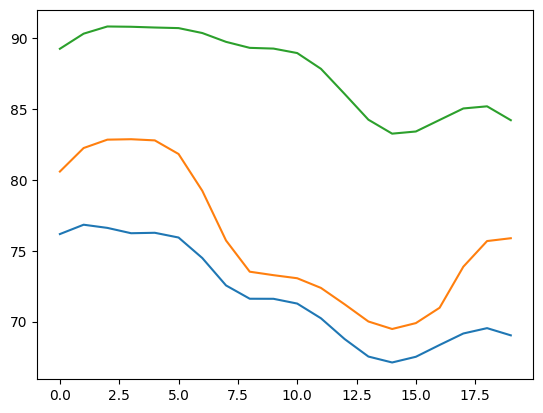

In [16]:
# parameters:
dataset_name = 'beignet'
# dataset_name = 'affi'
if dataset_name == 'beignet':
  num_channels = 89
else:
  num_channels = 239

batch_size = 32
num_epochs = 100
learning_rate = 1e-4
hidden_size = 1024
input_size = num_channels

# define dataloader
train_data, test_data, val_data = load_dataset(
    f'dataset/train_data_{dataset_name}.npz')  # B * T * C * F

# print the shape of the train, test, val data
print(f'train_data shape: {train_data.shape}')
print(f'test_data shape: {test_data.shape}')
print(f'val_data shape: {val_data.shape}')

# plot test_data curve for a few channels
import matplotlib.pyplot as plt
plt.plot(test_data[0, :, 0, 1])
plt.plot(test_data[0, :, 1, 1])
plt.plot(test_data[0, :, 2, 1])
plt.show()

In [ ]:

# define dataloader

train_data = NeuroForcastDataset(train_data, use_graph=False)

# Save train_data average and std one file
np.savez(f'train_data_average_std_{dataset_name}.npz', average=train_data.average, std=train_data.std)

test_data = NeuroForcastDataset(test_data, use_graph=False, average=train_data.average, std=train_data.std)
val_data = NeuroForcastDataset(val_data, use_graph=False, average=train_data.average, std=train_data.std)
train_data_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=16, shuffle=False)
val_data_loader = DataLoader(val_data, batch_size=16, shuffle=False)


# model = NFBaseModel(hidden_size=hidden_size, input_size=input_size)
model = NFSTNDTModel(hidden_size=hidden_size, input_size=input_size, n_heads=8, n_layers=6, dropout=0.1)
model = model.to(torch.device('cuda'))
# loss_fn = torch.nn.MSELoss('mean')
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# lambda1 = lambda ith_epoch: 0.95 ** (ith_epoch // 50)
# scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)

loss_fn = torch.nn.MSELoss(reduction="mean")
# Transformer/Attention 類模型建議用 AdamW + 較小 lr
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
# 讓 scheduler 每個 epoch 有小幅衰減（也可以先不用 scheduler）
lambda1 = lambda epoch: 0.95 ** (epoch // 20)   # 每 20 epoch 衰減一次
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda1)



trainer = Trainer(model, train_data_loader, test_data_loader,
               val_data_loader, loss_fn, optimizer, device= torch.device('cuda'), scheduler=scheduler,
               forecasting_mode='multi_step', init_steps = 10, save_path ='./model.pth', ckpt_path=None)

trainer.train(100)

#save the model
torch.save(model.state_dict(), f'model_{dataset_name}.pth')

Epoch 1/100:  66%|██████▌   | 23/35 [03:15<01:38,  8.19s/it, train_loss=269.052208, lr=3.00e-04]

In [ ]:
# Run one test event and compare the output with the target

# load the model
# model_test = NFBaseModel(hidden_size=hidden_size, input_size=input_size)
model_test = NFSTNDTModel(hidden_size=hidden_size, input_size=input_size, n_heads=8, n_layers=6, dropout=0.1)
model_test = model_test.to(torch.device('cuda'))
model_test.load_state_dict(torch.load(f'./model_{dataset_name}.pth'))


def prepare_data(data):
    init_steps = 10
    # forecasting_mode == 'multi_step':
    future_step = data.shape[1] - init_steps
    # masking out future dataset

    input_data = torch.cat([data[:, :init_steps], torch.repeat_interleave(
        data[:, init_steps-1:init_steps], future_step, dim=1)], dim=1)
    target_data = data

    return input_data, target_data


# define r2_score and mse_score
def r2_score(target_data, output):
    return 1 - (torch.sum((target_data - output) ** 2) / torch.sum(target_data ** 2))


def mse_score(target_data, output):
    return torch.mean((target_data - output) ** 2)


# define r2_score and mse_score using numpy
def r2_score_np(target_data, output):
    return 1 - (np.sum((target_data - output) ** 2) / np.sum(target_data ** 2))


def mse_score_np(target_data, output):
    return np.mean((target_data - output) ** 2)

# Run model inference and collect predictions


def run_model_inference(model, data_loader, device):
    """
    Run model inference on test data and collect predictions.

    Args:
        model: Trained model
        data_loader: Test data loader
        device: Device to run inference on

    Returns:
        predictions: Model predictions as numpy array
        targets: Ground truth targets as numpy array
    """
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(data_loader):
            batch = batch.to(device)

            # Prepare input and target data
            input_data, target_data = prepare_data(batch)
            output = model(input_data)

            # Store predictions and targets
            predictions.append(output.cpu().numpy())
            targets.append(target_data.cpu().numpy())

    # Concatenate all batches
    predictions = np.concatenate(predictions, axis=0)
    targets = np.concatenate(targets, axis=0)

    return predictions, targets


# Run inference
predictions, targets = run_model_inference(
    model_test, test_data_loader, torch.device('cuda'))

# Expose arrays for plotting
output_data_list = predictions
target_data_list = targets

# Calculate evaluation metrics
r2 = r2_score(torch.tensor(targets), torch.tensor(predictions))
mse = mse_score(torch.tensor(targets), torch.tensor(predictions))

# Calculate evaluation metrics using numpy
r2_np = r2_score_np(np.array(targets), np.array(predictions))
mse_np = mse_score_np(np.array(targets), np.array(predictions))

print(f'Test R2 score: {r2:.4f}')
print(f'Test MSE score: {mse:.4f}')
print(f'Test R2 score(NP): {r2_np:.4f}')
print(f'Test MSE score(NP): {mse_np:.4f}')

Test R2 score: -344.1872
Test MSE score: 21.8749
Test R2 score(NP): -344.1872
Test MSE score(NP): 21.8749


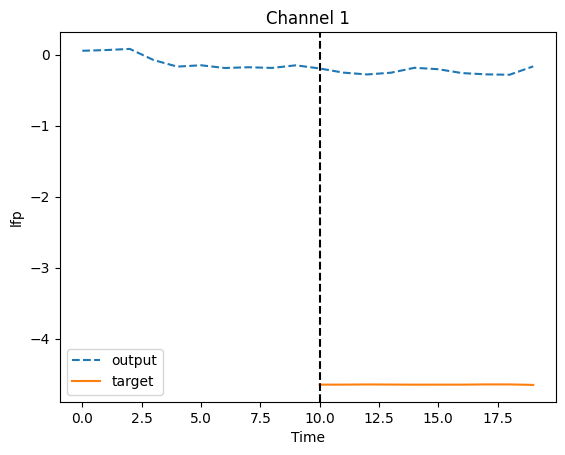

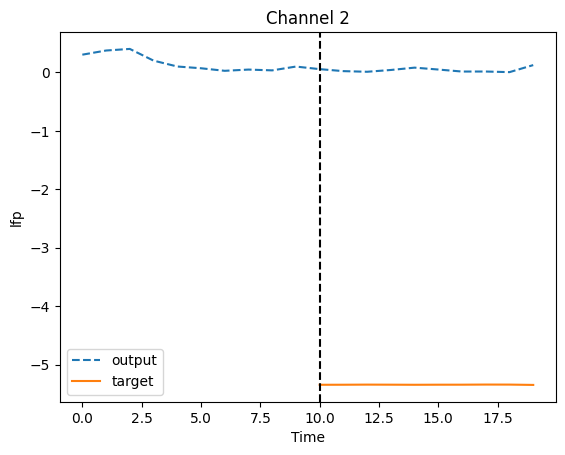

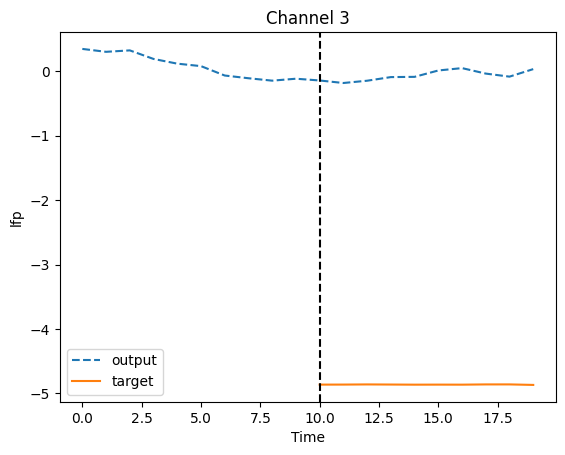

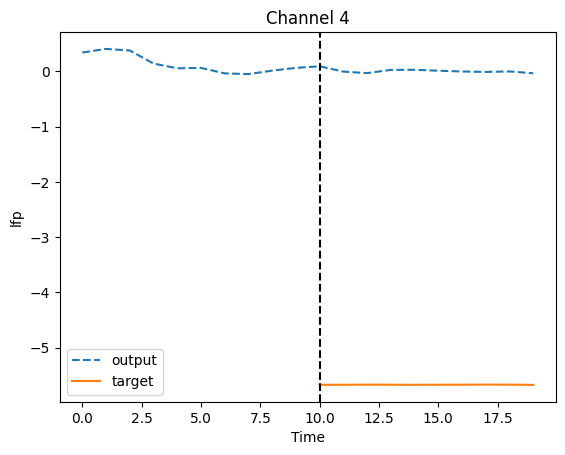

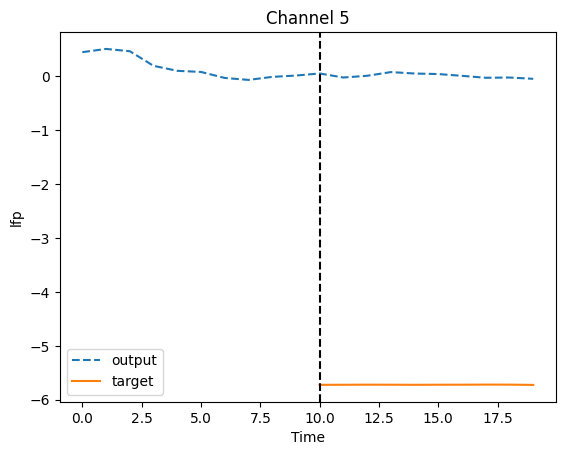

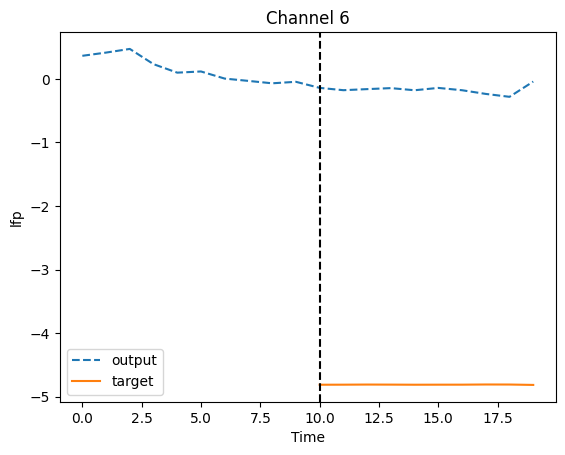

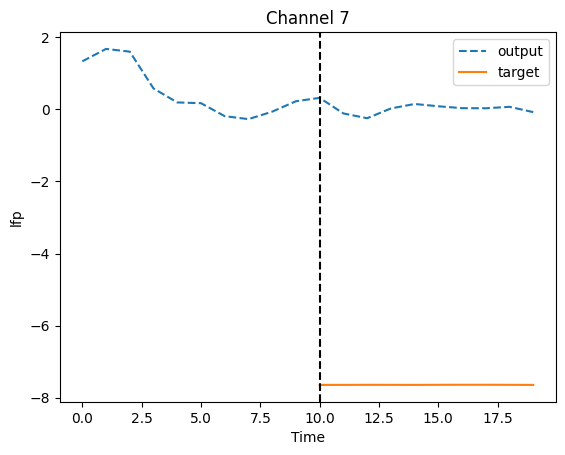

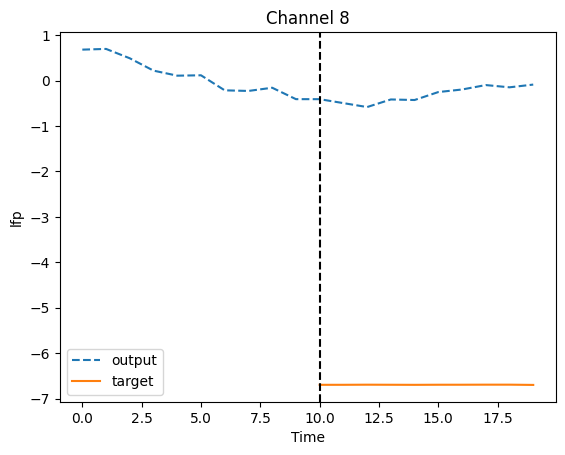

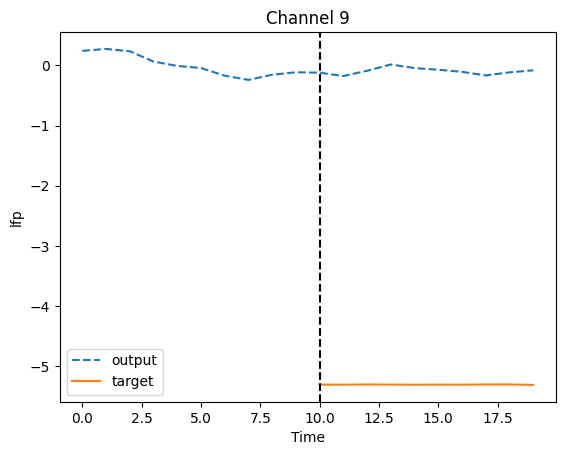

In [ ]:
# Compare the output and target data for 1st channel


channel_idx = 1

def plot_channel(channel_idx):
  # plot the output and target data (dotted line)
  # output_data_list start from x = 10 time steps
  plt.plot(target_data_list[0, :, channel_idx], linestyle='--', label='target')
  # Plot output data starting from the 10th time step
  x_output = np.arange(10, len(output_data_list[0, :, channel_idx]))
  plt.plot(x_output, output_data_list[0, 10:, channel_idx], linestyle='-', label='output')

  # Draw a vertical line at the 10th time step
  plt.axvline(x=10, color='black', linestyle='--')
  plt.legend(['output', 'target'])
  plt.title(f'Channel {channel_idx}')
  plt.xlabel('Time')
  plt.ylabel('lfp')
  plt.show()

plot_channel(1)
plot_channel(2)
plot_channel(3)
plot_channel(4)
plot_channel(5)
plot_channel(6)
plot_channel(7)
plot_channel(8)
plot_channel(9)